In [8]:
experiment_description = ("Experiment studying the effect of the temporal duration of the anomaly on the detection"
                          " performance of low-rank vs structured sparse tensor decomposition "
                          "algorithms with different regularizations for anomaly detection in spatio-temporal data. "
                          "This experiment compares the performances on three different types of anomalies. Namely, "
                          "all of the anomalies are spatio-temporally contiguous, but they differ in their spatial shapes.\n"
                          "\t - Case 1: Anomalies are on an undirected 2D cartesian 10x10 grid, isotropically distributed.\n"
                          "\t - Case 2: Anomalies are generated on a directed Gnm graph with 100 nodes and 250 edges. "
                            "isotropically distributed. Meaning, all nodes within radius distance are anomalous. \n"
                          "The normal part of the data is generated from a low-rank tensor of dimension (100,54,7,24), "
                          "with rank (7,7,4,6). The hyper-parameter search is done for 333 anomaly case for each algorithm using "
                          "Optuna. The best hyper-parameters are used for all cases. Experiments are repeated 12 times.\n"
                          "### The independent variables:\n"
                            "\t- The type of anomaly from the three options described above\n"
                            "\t- The algorithm used for anomaly detection: [HoRPCA, LR_LOGS, LR_LOGS_VAR]\n"
                            "\t- The type of graph structure: [2-D Grid, Random Gnm graph]\n"
                            "\t- Group anomaly temporal duration: [1,2,3,4,5,6]\n"  
                          "### The dependent variables:\n"
                          "\t- AUC-ROC score\n"
                          "\t- AUC-PRC score\n"
                          "\t- Relative reconstruction error (Anomaly and Normal)\n"
                          "### The control variables:\n"
                          "\t- Group Anomaly Shape in Space: Gaussian\n"
                          "\t- Group Anomaly Amplitudes sampled from: {-1,1} Bernoulli rv with p=0.5\n"
                          "\t- Tensor dimension (100,54,7,24) with ranks (7,7,4,6).\n"
                          # "\t- AWGNoise ~ N(0,1)\n"
                          "\t- Group anomaly radius/length : 2/9\n"
                          "\t- Number of anomaly groups = 250\n"
                          "----------------------------------------------------------------------------\n"
                          "HoRPCA parameters: mu=100, maxit=300, err_tol=1e-3\n"
                          "LR-LOGS parameters: step_size_growth=1.1, mu=100 maxit=300, err_tol=1e-3\n"
                          "## Hypothesis:"
                          "I expect the LR-LOGS algorithms with Edge grouping to do better than neighbor"
                          "grouping when the anomalies are generated as random walks."
                        )
experiment_tags = {"project_name": 'Anomaly Detection Experiments',
                    "tags": 'Anomaly Detection',
                'mlflow.note.content': experiment_description}


import sys
import os
from functools import partial
from pprint import pprint

import optuna
import torch
import numpy as np
import networkx as nx
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from dask.distributed import Client, wait

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# from src.gsp.gsp_vis import draw_graph_signal
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import hp_search_for_alg

print("Is cuda available?\t",torch.cuda.is_available())
print("How many cuda cores are available?\t",torch.cuda.device_count())

n_cores = 4
client = Client(n_workers=n_cores)
client

Is cuda available?	 True
How many cuda cores are available?	 4


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43679/status,
Dashboard: http://127.0.0.1:43679/status,Workers: 4
Total threads: 8,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33741,Workers: 4
Dashboard: http://127.0.0.1:43679/status,Total threads: 8
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:46257,Total threads: 2
Dashboard: http://127.0.0.1:40463/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:46343,


## Case 1

In [3]:
experiment_name = 'STGAD_Exp3_Case1'
uri = "http://127.0.0.1:8080"
mlflow_param = {'experiment_name': experiment_name, 'uri': uri, 'tags': experiment_tags}

search_param_1 = {'n_trials': 1, 'mean_over':4}
search_param = {'n_trials': 100, 'mean_over':4}
# The following is the configuration for the experiment

data_gen_param ={'lr_param': {'dim': (100,54,7,24), 'ranks': (7,7,4,6)},
                 'graph_param': {'graph_type': 'grid', 'dim': (10,10)},
                 'anomaly_param': {'NoA': 250, 'local_dist': 'gaussian', 
                                    'time_m': 3, 'local_m': 1, 
                                    'duration': 1, 'radius': 2, 
                                    'spread': 'isotropic'}
                }

selectors = []
selectors.append( {'name': 'HoRPCA','lr_modes':[1,2,3,4], 'verbose':0,
                    'mu':100, 'step_size_growth':1, 'maxit':80,
                    'err_tol':1e-3})


selectors.append( {'name':'LR_LOGS', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                        'r_hop': 1, 'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                        'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append(  {'name':'LR_LOGS', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                        'r_hop': 2, 'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                        'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S10', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S01', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S11', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S10T', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S01T', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})

selectors.append( {'name':'LR_LOGS_VAR', 'grouping': 'neighbor', 'weighing': 'size_normalized',
                               'var': 'S11T', 'r_hop': 1, 
                               'lr_modes':[1,2,3,4], 'verbose':0, 'rho_upd':1.1,
                               'rho_update_threshold':100, 'err_tol':1e-3, 'max_iter':80})


studies = []
for i, alg_selector in enumerate(selectors):
    if i <3:
        studies.append(
            hp_search_for_alg(alg_selector, data_gen_param, search_param_1, mlflow_param, 1, log_champion=True, client=client)
            )
    else:
        studies.append(
            hp_search_for_alg(alg_selector, data_gen_param, search_param, mlflow_param, 1, log_champion=True, client=client)
            )


LR_LOGS_gn_wd_r2
Trial 102 achieved AUC-ROC= 0.98458, AUC-PRC= 0.89790,  with 0.025% and 0.132% improvement.
{'lda_0': 0.3865464424930302,
 'psi_1': 0.37136739060774937,
 'psi_2': 1.4978152978541215,
 'psi_3': 0.000322283988090138,
 'psi_4': 0.0003063568102342822,
 'rho': 0.006318318074706293}
LR_LOGS_VAR_S10_gn_wd_r1
Trial 110 achieved AUC-ROC= 0.98844, AUC-PRC= 0.91631,  with 0.158% and 25.930% improvement.
{'lda_0': 1506.9406552284,
 'lda_1': 1153.9307603457128,
 'psi_1': 0.08876472117160107,
 'psi_2': 7.392455854980093,
 'psi_3': 0.00034613740293350774,
 'psi_4': 1.0660843822072812,
 'rho': 0.06312679658280858}
LR_LOGS_VAR_S10_gn_wd_r1
Trial 182 achieved AUC-ROC= 0.99030, AUC-PRC= 0.87019,  with 0.187% and 5.299% improvement.
{'lda_0': 21.944725819365768,
 'lda_1': 102.08541796525452,
 'psi_1': 1.9888223046507214,
 'psi_2': 0.30966115227469965,
 'psi_3': 0.023260477754281184,
 'psi_4': 0.0005322832876800996,
 'rho': 0.27339503550934285}
LR_LOGS_VAR_S01_gn_wd_r1
Trial 5 achieved AUC

Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S10_gn_wd_r1
Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S01_gn_wd_r1
Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S11_gn_wd_r1
Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S10T_gn_wd_r1
Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S01T_gn_wd_r1
Running STGAD_Exp3_Case1grid_isotropicLR_LOGS_VAR_S11T_gn_wd_r1


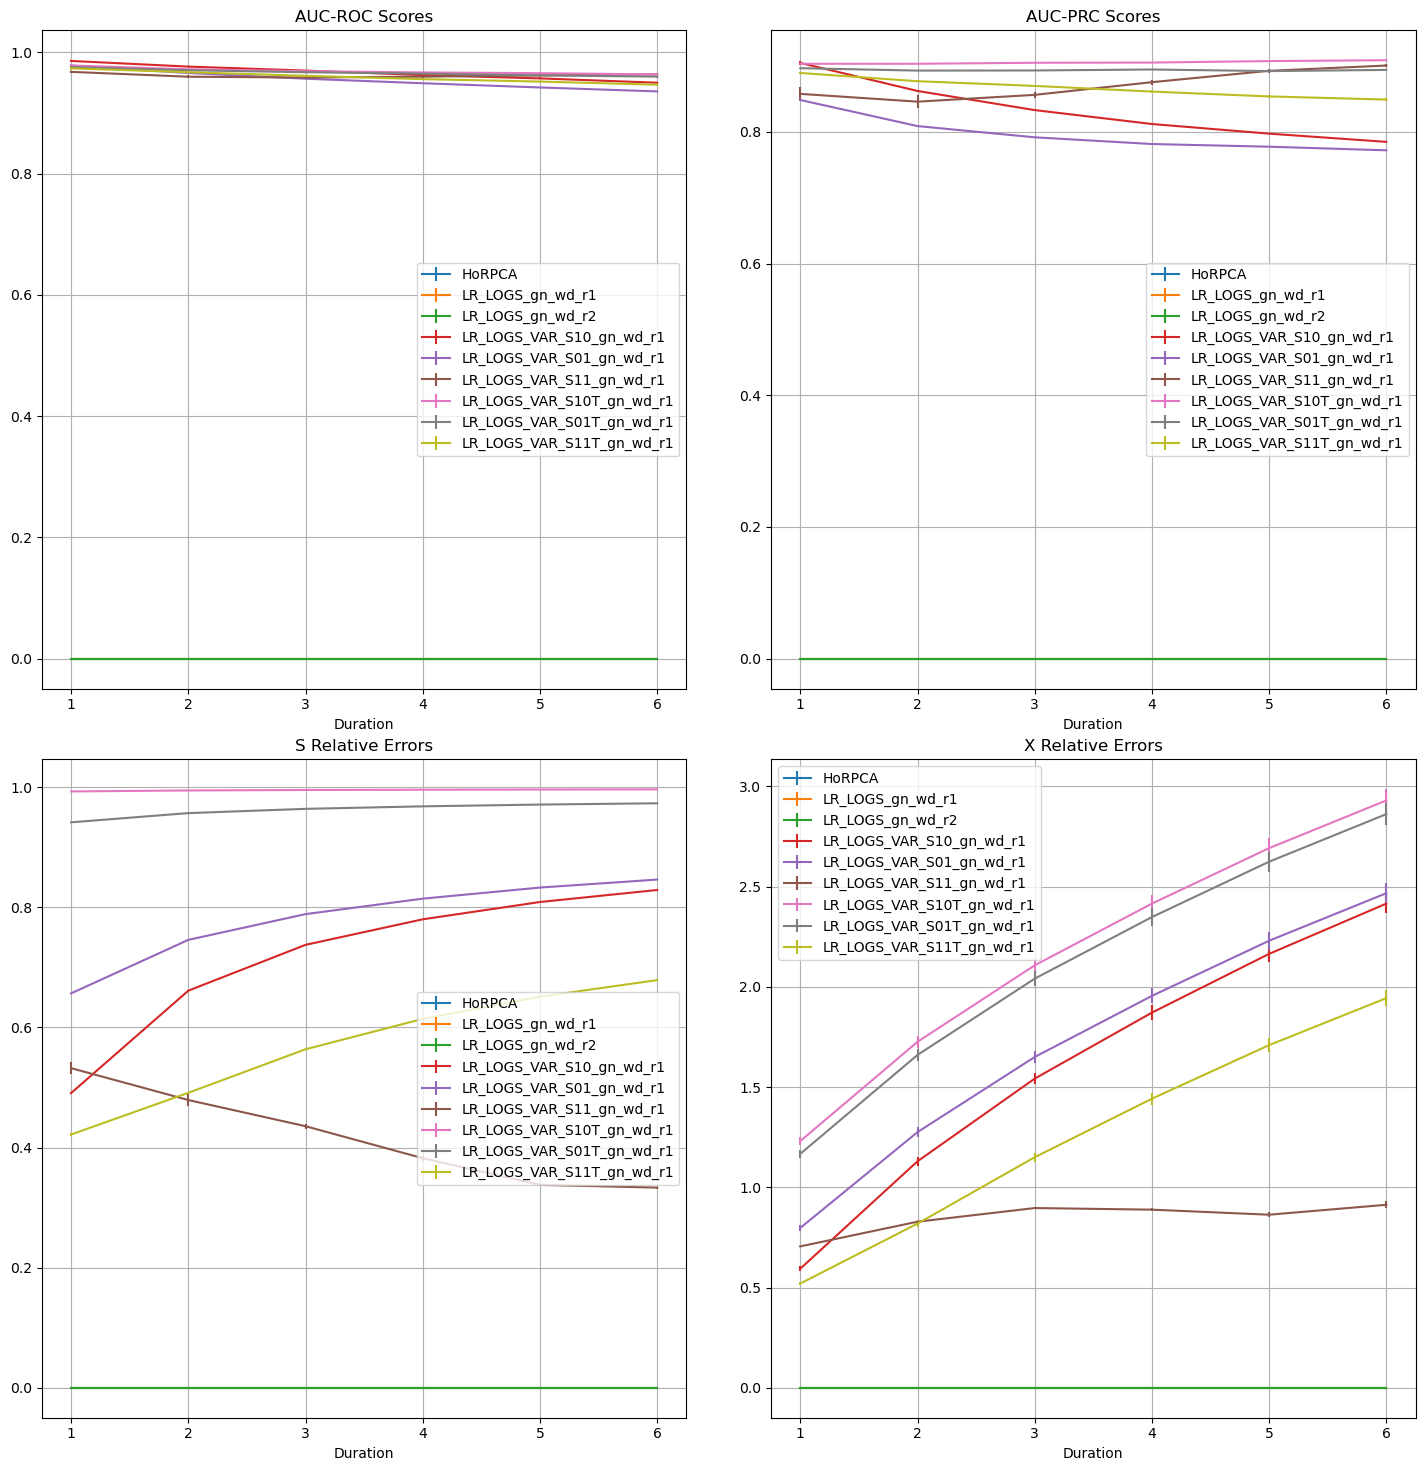

In [13]:
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import selector_to_str
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import run_algorithm
from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import get_or_create_experiment
# from experiment_board.st_anomaly_exps.st_group_anomaly_experiment_utils import plot_exp3_results

experiment_name = mlflow_param['experiment_name']
tags = mlflow_param['tags']
experiment_id = get_or_create_experiment(experiment_name, tags)
mlflow.set_tracking_uri(uri)
mlflow.set_experiment(experiment_id=experiment_id)

data_gen_param ={'lr_param': {'dim': (100,54,7,24), 'ranks': (7,7,4,6)},
                 'graph_param': {'graph_type': 'grid', 'dim': (10,10)},
                 'anomaly_param': {'NoA': 1000, 'local_dist': 'gaussian', 
                                    'time_m': 4, 'local_m': 1, 
                                    'duration': 1, 'radius': 2, 
                                    'spread': 'isotropic'}
                }

duration = [1,2,3,4,5,6]
NoT = 4

abbreviations = [selector_to_str(selector) for selector in selectors]

auc_prc_scores = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
auc_roc_scores = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
S_rec_errors = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}
X_rec_errors = {abbr: np.zeros((len(duration), NoT)) for abbr in abbreviations}

run_name = 'STGAD_Exp3_Case1' + f'{data_gen_param["graph_param"]["graph_type"]}_{data_gen_param["anomaly_param"]["spread"]}'

# with mlflow.start_run(run_name=run_name, nested=True):
#     mlflow.log_params(data_gen_param['lr_param'])
#     mlflow.log_params(data_gen_param['graph_param'])
#     mlflow.log_params(data_gen_param['anomaly_param'])
#     mlflow.set_tags({'graph_type': data_gen_param['graph_param']['graph_type'],
#                      'anomaly_spread': data_gen_param['anomaly_param']['spread']})
#     print("logged exp parameters")
for i in range(len(selectors)):
    selector = selectors[i]
    alg_run_name = run_name + selector_to_str(selector)
    study = studies[i]
    best_params = max(study.best_trials, key= lambda da: da.values[1]).params
    if selector['name'] == 'HoRPCA':
        alg_param = {'lda_nucs': [1.0] + [best_params['psi_2'], best_params['psi_3'], best_params['psi_4']],
                        'lda1': best_params['lda1'], 'rho': best_params['rho']}
    elif selector['name']=='LR_LOGS':
        alg_param = {'lda_f':100.0, 
                        'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3'], best_params['psi_3']],
                        'lda_0': best_params['lda_0'],
                        'rho': best_params['rho']
                        }
    elif selector['name']=='LR_LOGS_VAR':
        alg_param = {'lda_f':100.0, 
                        'psis':[best_params['psi_1'], best_params['psi_2'], best_params['psi_3'], best_params['psi_3']],
                        'lda_0': best_params['lda_0'],
                        'rho': best_params['rho'],
                        'lda_1': best_params.get('lda_1',0),
                        'lda_2': best_params.get('lda_2',0),
                        'lda_t': best_params.get('lda_t',0)
                        }
    # with mlflow.start_run(run_name=alg_run_name, nested=True):
        print(f"Running {alg_run_name}")
        for j, duration_i in enumerate(duration):
            d_gen_param = data_gen_param.copy()
            d_gen_param['anomaly_param']['duration'] = duration_i
            futures = []
            n_active_task = 0
            for t in range(NoT):
                if n_active_task == 4:
                    wait(futures)
                    n_active_task = 0
                device = f'cuda:{n_active_task}'
                seed = t + 32132
                futures.append(client.submit(run_algorithm, d_gen_param, selector, alg_param,  seed, device))
                n_active_task += 1
        
            results = client.gather(futures)
            auc_roc_scores[abbreviations[i]][j, :] = np.array([result['AUC_ROC'] for result in results])
            auc_prc_scores[abbreviations[i]][j, :] = np.array([result['AUC_PRC'] for result in results])
            S_rec_errors[abbreviations[i]][j, :] = np.array([result['S_relative_error'] for result in results])
            X_rec_errors[abbreviations[i]][j, :] = np.array([result['X_relative_error'] for result in results])
fig, axs = plot_exp3_results(duration, auc_roc_scores, auc_prc_scores, S_rec_errors, X_rec_errors, abbreviations)
# mlflow.log_figure(fig, 'AUC_ROC_AUC_PRC_S_X_Relative_Errors.png')

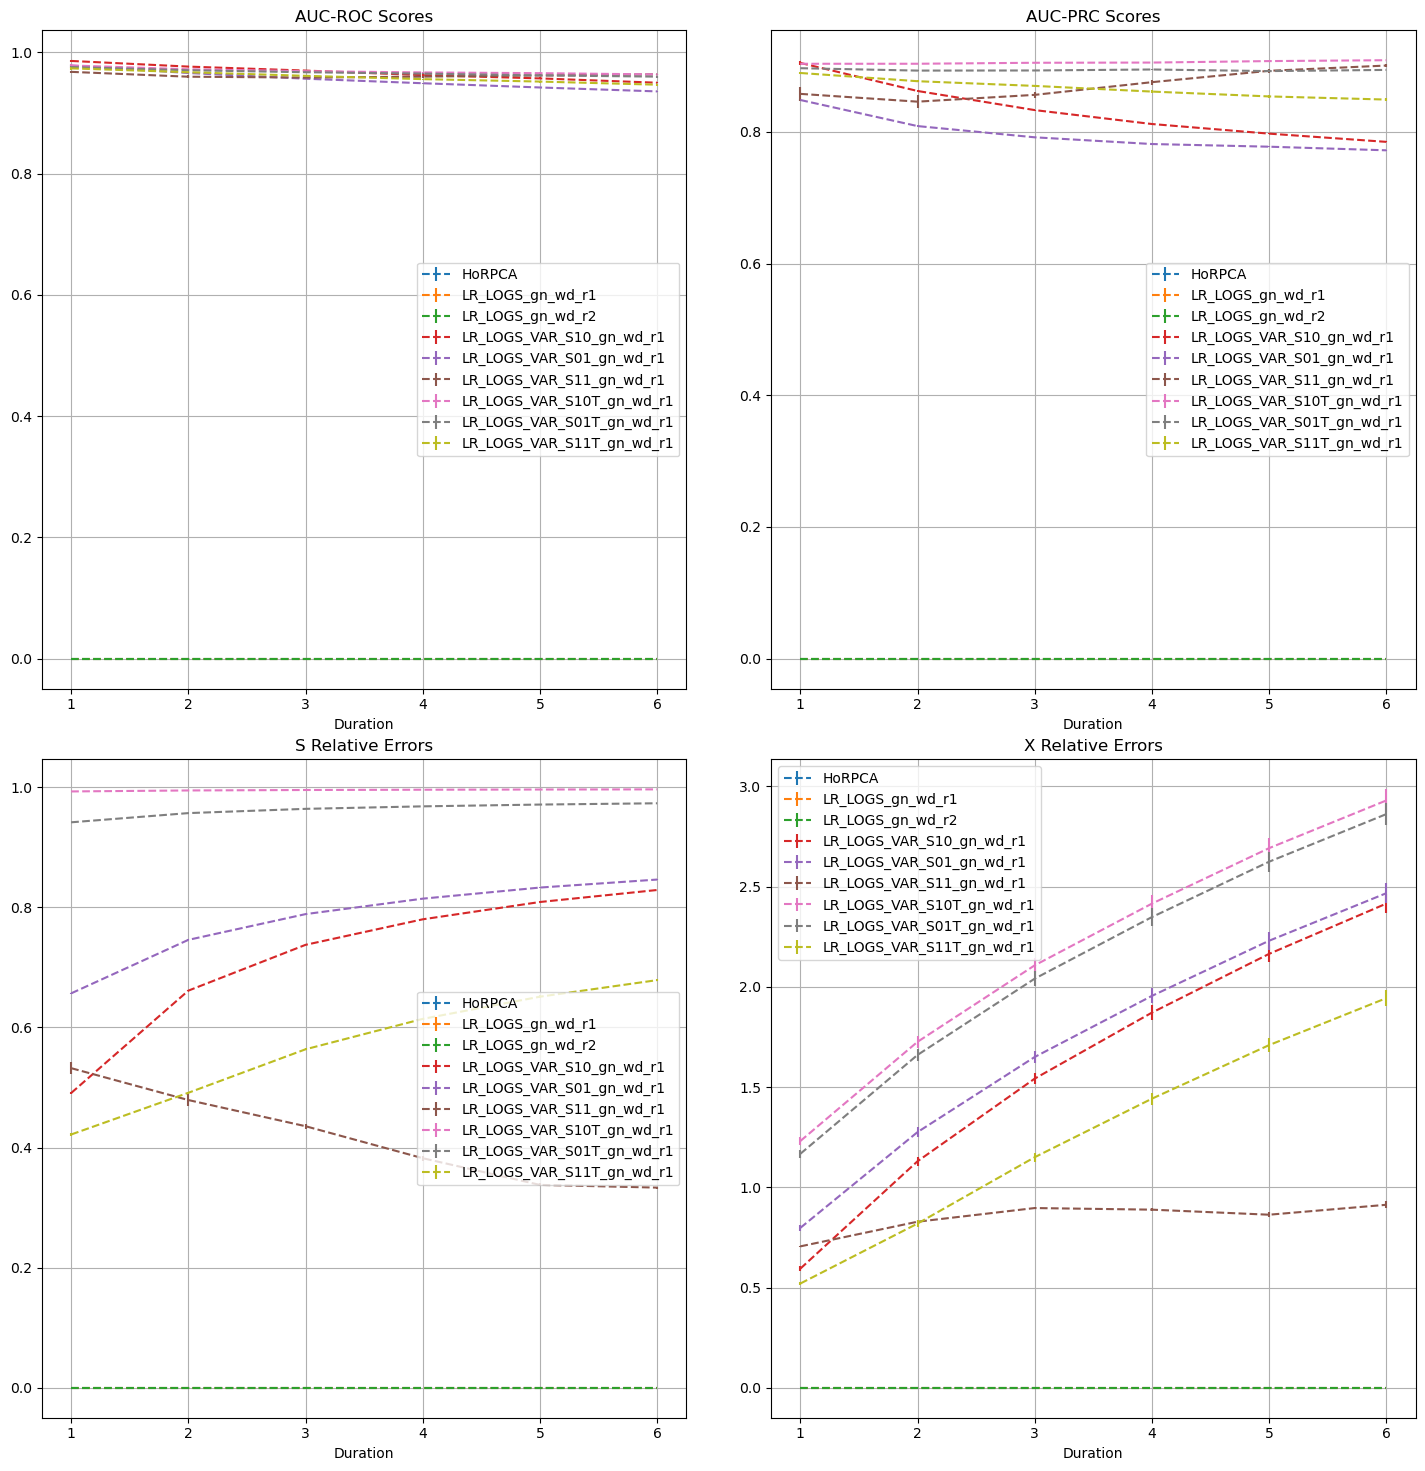

In [16]:
import matplotlib.pyplot as plt

def plot_exp3_results(NoA, auc_roc_scores,auc_prc_scores, S_rec_errors, X_rec_errors, algorithms):
    fig, axs = plt.subplots(2, 2, figsize=(15,15))
    fig.tight_layout(pad=3.0)
    for algo in algorithms:
        color = None
        if 'VAR' in algo:
            linestyle = '--'
        elif algo == 'HoRPCA':
            linestyle = '-.'
            color = 'black'
        else:
            linestyle = '-'
        # if 'T' in 'algo':
        #     linestyle = ':'
    for algo in algorithms:
        axs[0,0].errorbar(NoA, np.mean(auc_roc_scores[algo], axis=1), np.std(auc_roc_scores[algo], axis=1), label=algo,
                         linestyle=linestyle, color=color)
        axs[0,1].errorbar(NoA, np.mean(auc_prc_scores[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo,
                         linestyle=linestyle, color=color)
        axs[1,0].errorbar(NoA, np.mean(S_rec_errors[algo], axis=1), np.std(S_rec_errors[algo], axis=1), label=algo,
                         linestyle=linestyle, color=color)
        axs[1,1].errorbar(NoA, np.mean(X_rec_errors[algo], axis=1), np.std(X_rec_errors[algo], axis=1), label=algo,
                         linestyle=linestyle, color=color)
    axs[0,0].set_title('AUC-ROC Scores')
    axs[0,1].set_title('AUC-PRC Scores')
    axs[1,0].set_title('S Relative Errors')
    axs[1,1].set_title('X Relative Errors')
    
    for ax in axs.flat:
        ax.set_xlabel('Duration')
        ax.legend()
        ax.grid()
    return fig, axs

fig, axs = plot_exp3_results(duration, auc_roc_scores, auc_prc_scores, S_rec_errors, X_rec_errors, abbreviations)